# Linear regression with one variable

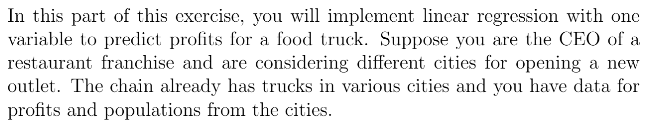

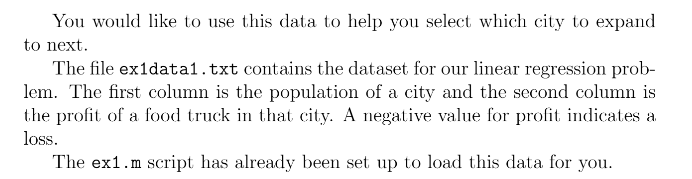

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

### Loading the data

In [72]:
data = pd.read_csv("data//ex1data1.txt", header = None).rename(columns={0:"Population", 1:"Profit"})
data

,Population,Profit
0,6.1101,17.59200
1,5.5277,9.13020
2,8.5186,13.66200
3,7.0032,11.85400
4,5.8598,6.82330
...,...,...
92,5.8707,7.20290
93,5.3054,1.98690
94,8.2934,0.14454
95,13.3940,9.05510


### Visualizing the data

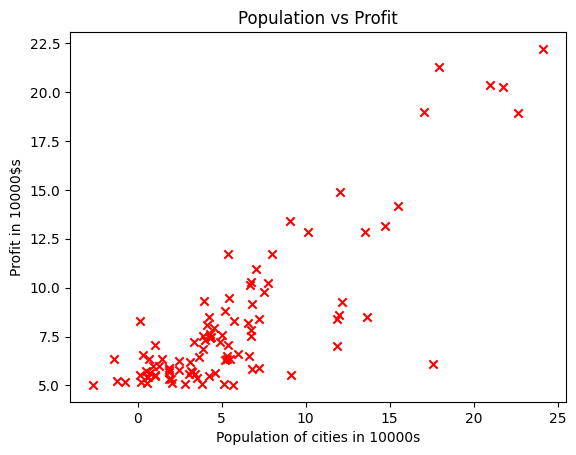

In [74]:
fig, ax = plt.subplots()
ax.scatter(data['Profit'], data["Population"], marker = 'x', c = 'r')
plt.title("Population vs Profit")
plt.ylabel("Profit in 10000$s")
plt.xlabel("Population of cities in 10000s")
plt.show()

### Dividing the data 

In [75]:
X = np.array(data['Profit'])
Y = np.array(data['Population'])

### Creating a model

In [76]:
def predict_and_plot(x,w,b):
    pred = np.dot(w,x) + b
    fig, ax = plt.subplots()
    ax.scatter(data['Profit'], data["Population"], marker = 'x', c = 'r')
    plt.title("Population vs Profit")
    plt.ylabel("Profit in 10000$s")
    plt.xlabel("Population of cities in 10000s")
    ax.plot(x,pred)
    plt.show()
    return pred

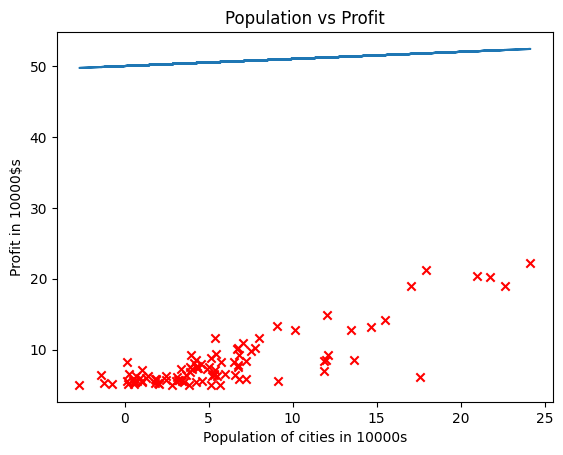

array([51.7592  , 50.91302 , 51.3662  , 51.1854  , 50.68233 , 51.1886  ,
       50.43483 , 51.2     , 50.65987 , 50.38166 , 50.32522 , 51.5505  ,
       50.31551 , 50.72258 , 50.071618, 50.35129 , 50.53048 , 50.056077,
       50.36518 , 50.53893 , 50.31386 , 52.1767  , 50.4263  , 50.51875 ,
       50.30825 , 52.2638  , 51.3501  , 50.70467 , 51.4692  , 52.4147  ,
       49.878   , 50.59966 , 51.2134  , 50.18495 , 50.65426 , 50.45623 ,
       50.41164 , 50.33928 , 51.0117  , 50.54974 , 50.055657, 50.39115 ,
       50.53854 , 50.24406 , 50.67318 , 50.10463 , 50.51337 , 50.1844  ,
       50.80043 , 50.10179 , 50.67504 , 50.18396 , 50.42885 , 50.49981 ,
       50.14233 , 49.85789 , 50.24756 , 50.46042 , 50.39624 , 50.54141 ,
       50.51694 , 49.925721, 51.7929  , 51.2054  , 51.7054  , 50.48852 ,
       50.57442 , 50.77754 , 50.10173 , 52.0992  , 50.66799 , 50.40259 ,
       50.12784 , 50.33411 , 49.73193 , 50.029678, 50.38845 , 50.57014 ,
       50.67526 , 50.20576 , 50.047953, 50.020421, 

In [77]:
predict_and_plot(X,0.1, 50)

In [78]:
def error(y,predicted):
    err = (predicted-y)**2
    return err

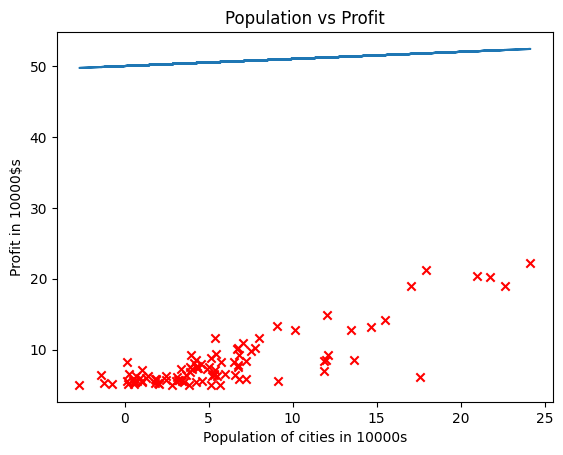

array([2083.84033081, 2059.8272715 , 1835.91682576, 1952.06679684,
       2009.0591956 , 1832.32795249, 1845.42670806, 1816.62635961,
       1951.31312127, 2054.54236824, 1990.45539483, 1397.75038225,
       1987.51103388, 1790.48982907, 1974.10647432, 2022.47089017,
       1950.55429141, 2018.3434094 , 1930.33518994, 1889.4783257 ,
       1946.99444506, 1018.03750489, 2019.26207044, 1952.99031402,
       2001.96736922, 1110.14243344, 1483.95218841, 1579.87727043,
       1466.36916624,  912.74681689, 1991.44417536, 1936.90298527,
       1761.07801104, 1961.88313692, 1801.42183079, 1808.19107121,
       1790.62185175, 2001.03949968, 1457.38407049, 1953.3164694 ,
       1993.51150165, 1893.00262482, 1507.81083669, 1977.61291853,
       1835.99223831, 1849.99171294, 2065.08169965, 1969.850689  ,
       1528.84362618, 1985.61053284, 1860.61442183, 2013.87871159,
       1849.4257245 , 1840.12772882, 1919.27491882, 1892.16213102,
       1933.65638969, 2008.89694132, 1688.06268288, 1688.20813

In [86]:
error(Y, predict_and_plot(X,0.1, 50))

### Computing the gradient

In [87]:
def compute_gradient(x,y,w,b): 
    initial_w = 0
    initial_b = 0
    m = x.shape[0]   
    for i in range(m):
        err = (np.dot(x[i], w)+b)-y[i]
        initial_w = initial_w + (err * x[i])
        initial_b = initial_b + err
    initial_w = initial_w/m
    initial_b = initial_b/m
    return initial_w, initial_b

In [88]:
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(X, Y, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.32884974555672 -8.159800000000002


In [101]:
def calculate_gradientDesent(x,y,w,b,gradient_function,alpha,num_iter):
    for i in range(num_iter):
        initial_w,initial_b = gradient_function(x,y,w,b)
        w = w - (alpha * initial_w)
        b = b - (alpha * initial_b)
    return w,b

In [102]:
calculate_gradientDesent(X, Y, 0.1,50,compute_gradient, 0.01,1500)

(np.float64(0.58462795003486), np.float64(4.76540515755597))

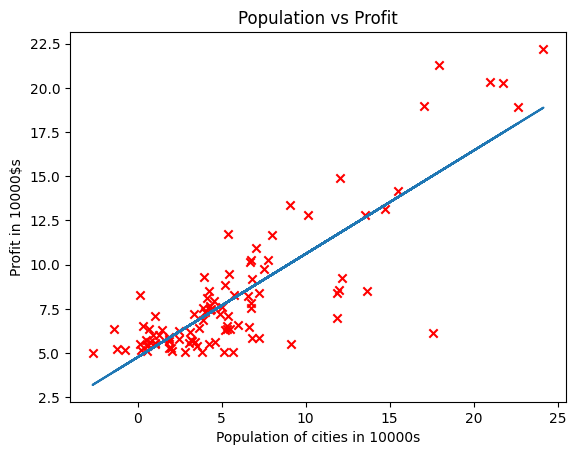

array([15.05018005, 10.10317527, 12.75259221, 11.69558488,  8.75449705,
       11.71429297,  7.30754287, 11.78094056,  8.62318961,  6.99669619,
        6.66673218, 13.83006152,  6.6099648 ,  8.9898098 ,  5.184104  ,
        6.81914468,  7.86673951,  5.09324697,  6.90034951,  7.91614057,
        6.60031844, 17.49100175,  7.25767411,  7.79816265,  6.56752081,
       18.00021269, 12.65846711,  8.88510293, 13.354759  , 18.88241627,
        4.05215906,  8.27118512, 11.8592807 ,  5.84667455,  8.59039198,
        7.43265325,  7.17196765,  6.74893087, 10.68008613,  7.97933885,
        5.09079154,  7.05217738,  7.91386052,  6.19224813,  8.70100359,
        5.37710138,  7.76670966,  5.8434591 ,  9.44494266,  5.36049795,
        8.71187767,  5.84088673,  7.27258212,  7.68743411,  5.59750612,
        3.93459038,  6.21271011,  7.45714917,  7.08193495,  7.93063934,
        7.78758088,  4.33114936, 15.24719967, 11.81251047, 14.73565022,
        7.62142962,  8.12362503,  9.31112132,  5.36014717, 17.03

In [104]:
predict_and_plot(X,0.58462795003486, 4.76540515755597)

So the ideal value for w and b <br> w = 0.58462795003486 <br> b = 4.76540515755597

In [105]:
w = 0.58462795003486
b = 4.76540515755597

### Enter for predictions

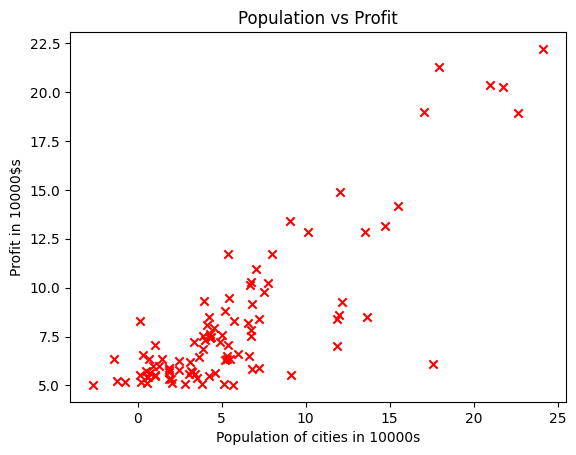

The predicted profit would be: 82731.73$


In [110]:
print(f"The predicted profit would be: {float(predict_and_plot(6, w, b)*10000):.2f}$")